In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    classification_report
)

In [4]:
df = pd.read_csv("loan.csv", nrows=200000, low_memory=False)

print(df.shape)

(181282, 145)


In [5]:
df = df[[
    "loan_amnt",
    "annual_inc",
    "int_rate",
    "loan_status",
    "grade",
    "emp_length",
    "home_ownership",
    "purpose",
    "term"
]]

In [6]:
df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])]

df["loan_status"] = df["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1
})

In [7]:
# grade mapping
grade_map = {
    "A": 7,
    "B": 6,
    "C": 5,
    "D": 4,
    "E": 3,
    "F": 2,
    "G": 1
}

df["grade_score"] = df["grade"].map(grade_map)

In [8]:
# employment length
df["emp_length"] = (
    df["emp_length"]
    .astype(str)
    .str.extract(r"(\d+)")
    .astype(float)
)

df["emp_length"].fillna(0, inplace=True)

In [9]:
# loan term
df["term"] = df["term"].str.extract(r"(\d+)").astype(int)

In [10]:
df = pd.get_dummies(
    df,
    columns=["home_ownership", "purpose"],
    drop_first=True
)

In [11]:
# removing nulls
df.dropna(inplace=True)

In [13]:
X = df.drop(columns=["loan_status", "grade"])
y = df["loan_status"]

print(X.shape)
print(y.shape)

(6075, 20)
(6075,)


In [14]:
# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [15]:
model = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [16]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.9728395061728395
[[1182    1]
 [  32    0]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1183
           1       0.00      0.00      0.00        32

    accuracy                           0.97      1215
   macro avg       0.49      0.50      0.49      1215
weighted avg       0.95      0.97      0.96      1215



In [17]:
# generating risk scores
df["risk_prob"] = model.predict_proba(X)[:, 1]

In [18]:
# risk categories
def risk_level(p):
    if p > 0.20:
        return "High Risk"
    elif p > 0.05:
        return "Medium Risk"
    else:
        return "Low Risk"

df["risk"] = df["risk_prob"].apply(risk_level)

In [19]:
print(df.groupby("risk")["loan_status"].mean())

risk
High Risk      0.859060
Low Risk       0.004814
Medium Risk    0.015773
Name: loan_status, dtype: float64


In [20]:
# Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                       Feature  Importance
1                   annual_inc    0.212927
0                    loan_amnt    0.199060
2                     int_rate    0.179756
3                   emp_length    0.116212
5                  grade_score    0.070687
6      home_ownership_MORTGAGE    0.030596
4                         term    0.028370
10  purpose_debt_consolidation    0.026918
9          purpose_credit_card    0.025713
8          home_ownership_RENT    0.020086


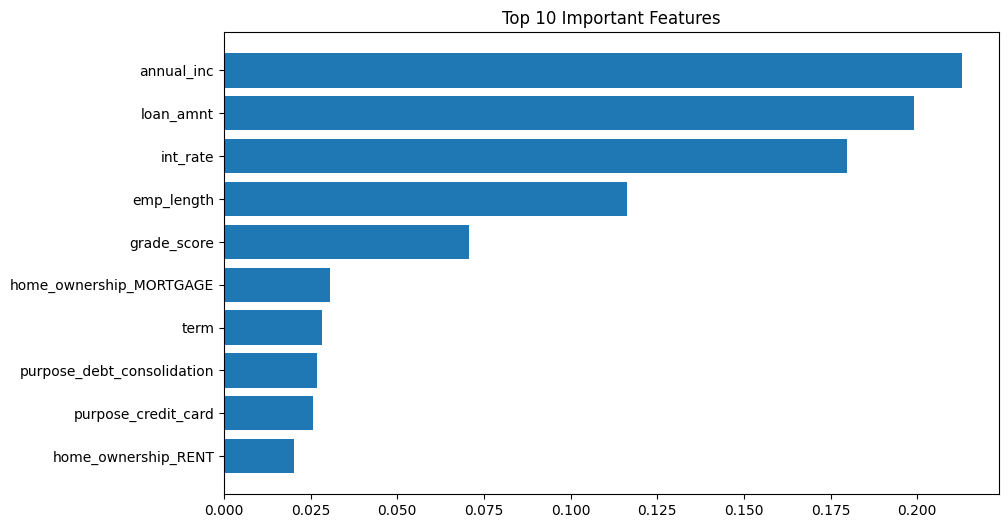

In [21]:
# Visualization
top_features = importance.head(10)

plt.figure(figsize=(10,6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Important Features")
plt.show()

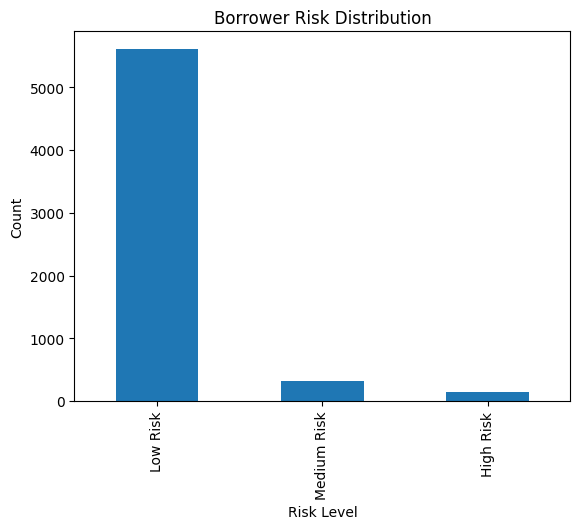

In [22]:
# risk dsitribution graph 
df["risk"].value_counts().plot(kind="bar")

plt.title("Borrower Risk Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")

plt.show()

In [34]:
# Loan Recommendation System
# Goal - Recommend a safe loan amount based on borrower risk.

def recommend_loan(row):
    if row["risk"] == "Low Risk":
        return row["annual_inc"] * 0.4

    elif row["risk"] == "Medium Risk":
        return row["annual_inc"] * 0.2

    else:
        return 2000


# Create recommendation column

df["recommended_loan"] = df.apply(recommend_loan, axis=1)

print(df[["risk", "recommended_loan"]].head())

         risk  recommended_loan
100  Low Risk           40000.0
152  Low Risk           18000.0
170  Low Risk           40000.0
186  Low Risk           15400.0
215  Low Risk          180000.0


In [35]:
# Dynamic Interest Recommendation System
# Goal - Generate fair interest rates based on borrower risk.

def interest_engine(risk):
    if risk == "Low Risk":
        return 8

    elif risk == "Medium Risk":
        return 12

    else:
        return 18


# Create interest recommendation

df["recommended_interest"] = df["risk"].apply(interest_engine)

print(df[["risk", "recommended_interest"]].head())

         risk  recommended_interest
100  Low Risk                     8
152  Low Risk                     8
170  Low Risk                     8
186  Low Risk                     8
215  Low Risk                     8


In [36]:
# Explainable AI Layer
# Goal - Provide reasons behind risk predictions. This makes the system more transparent and realistic.

def explain_risk(row):

    reasons = []

    if row["int_rate"] > 15:
        reasons.append("High existing interest rate")

    if row["emp_length"] < 2:
        reasons.append("Low employment stability")

    if row["annual_inc"] < 40000:
        reasons.append("Low annual income")

    if len(reasons) == 0:
        reasons.append("Strong financial profile")

    return ", ".join(reasons)


# Generate explanations

df["risk_reason"] = df.apply(explain_risk, axis=1)

print(df[["risk", "risk_reason"]].head())

         risk                                        risk_reason
100  Low Risk                        High existing interest rate
152  Low Risk  High existing interest rate, Low employment st...
170  Low Risk                           Strong financial profile
186  Low Risk                                  Low annual income
215  Low Risk                        High existing interest rate


In [37]:
# Progressive Trust System
# Goal Reward financially responsible borrowers.

def trust_level(row):

    if row["risk"] == "Low Risk":
        return "Gold"

    elif row["risk"] == "Medium Risk":
        return "Silver"

    else:
        return "Bronze"


# Create trust level

df["trust_level"] = df.apply(trust_level, axis=1)

print(df[["risk", "trust_level"]].head())

         risk trust_level
100  Low Risk        Gold
152  Low Risk        Gold
170  Low Risk        Gold
186  Low Risk        Gold
215  Low Risk        Gold


In [38]:
# Fraud Awareness Logic
# Goal - Identify potentially suspicious borrowers.

def fraud_flag(row):

    if row["loan_amnt"] > row["annual_inc"]:
        return "Suspicious"

    if row["emp_length"] < 1:
        return "Review Required"

    return "Normal"


# Fraud awareness output

df["fraud_status"] = df.apply(fraud_flag, axis=1)

print(df[["fraud_status"]].head())

    fraud_status
100       Normal
152       Normal
170       Normal
186       Normal
215       Normal


                       Feature  Importance
1                   annual_inc    0.212927
0                    loan_amnt    0.199060
2                     int_rate    0.179756
3                   emp_length    0.116212
5                  grade_score    0.070687
6      home_ownership_MORTGAGE    0.030596
4                         term    0.028370
10  purpose_debt_consolidation    0.026918
9          purpose_credit_card    0.025713
8          home_ownership_RENT    0.020086


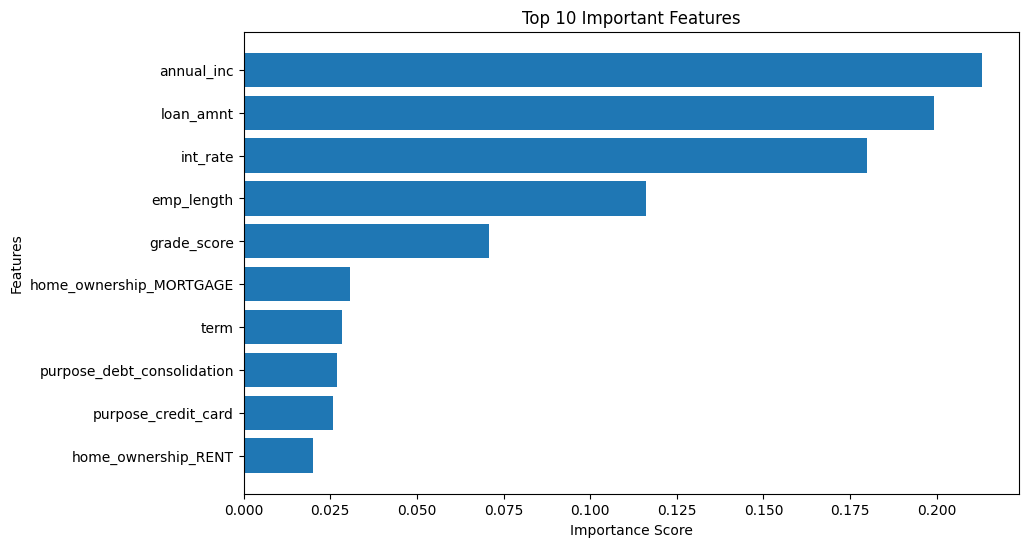

In [39]:
# Feature Importance Visualization
# Goal - Understand which borrower features influence risk prediction most.

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))


# visualization
plt.figure(figsize=(10,6))

plt.barh(
    importance.head(10)["Feature"],
    importance.head(10)["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

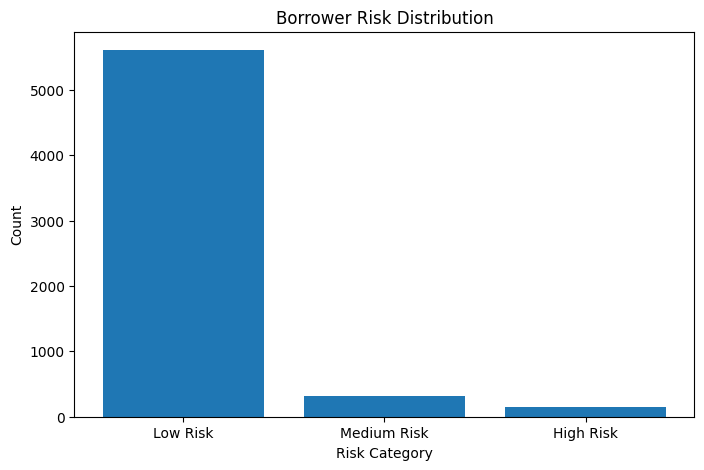

In [31]:
plt.figure(figsize=(8,5))

risk_counts = df["risk"].value_counts()

plt.bar(risk_counts.index, risk_counts.values)

plt.title("Borrower Risk Distribution")

plt.xlabel("Risk Category")

plt.ylabel("Count")

plt.show()

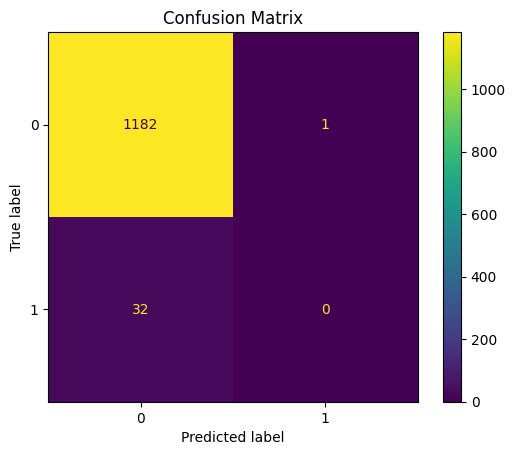

In [40]:
# Confusion Matrix Visualization
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")

plt.show()

In [41]:
# Simulated suspicious borrowers

fraud_samples = pd.DataFrame({
    "loan_amnt": [500000, 300000, 700000],
    "annual_inc": [20000, 15000, 10000],
    "int_rate": [24, 26, 30],
    "emp_length": [0, 1, 0],
    "term": [60, 60, 60],
    "grade_score": [1, 1, 1]
})

print(fraud_samples)

   loan_amnt  annual_inc  int_rate  emp_length  term  grade_score
0     500000       20000        24           0    60            1
1     300000       15000        26           1    60            1
2     700000       10000        30           0    60            1


In [42]:
# Fraud detection engine

def fraud_flag(row):

    # Very large loan compared to income
    if row["loan_amnt"] > row["annual_inc"] * 5:
        return "High Fraud Risk"

    # Extremely unstable profile
    if row["emp_length"] < 1 and row["int_rate"] > 20:
        return "Suspicious"

    return "Normal"


# Apply fraud logic

df["fraud_status"] = df.apply(fraud_flag, axis=1)

print(df[["loan_amnt", "annual_inc", "fraud_status"]].head())

     loan_amnt  annual_inc fraud_status
100      30000    100000.0       Normal
152      40000     45000.0       Normal
170      20000    100000.0       Normal
186       4500     38500.0       Normal
215       8425    450000.0       Normal


In [43]:
# Apply fraud logic on simulated fraud users

fraud_samples["fraud_status"] = fraud_samples.apply(
    fraud_flag,
    axis=1
)

print(fraud_samples)

   loan_amnt  annual_inc  int_rate  emp_length  term  grade_score  \
0     500000       20000        24           0    60            1   
1     300000       15000        26           1    60            1   
2     700000       10000        30           0    60            1   

      fraud_status  
0  High Fraud Risk  
1  High Fraud Risk  
2  High Fraud Risk  


In [44]:
# Feature importance dataframe

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

                       Feature  Importance
1                   annual_inc    0.212927
0                    loan_amnt    0.199060
2                     int_rate    0.179756
3                   emp_length    0.116212
5                  grade_score    0.070687
6      home_ownership_MORTGAGE    0.030596
4                         term    0.028370
10  purpose_debt_consolidation    0.026918
9          purpose_credit_card    0.025713
8          home_ownership_RENT    0.020086


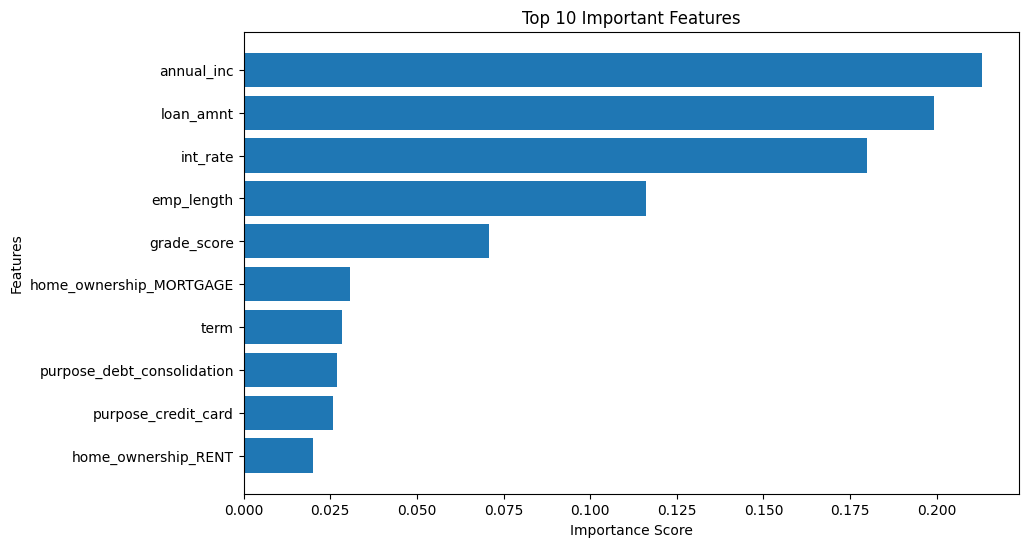

In [45]:
# Plot feature importance

plt.figure(figsize=(10,6))

plt.barh(
    importance.head(10)["Feature"],
    importance.head(10)["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.xlabel("Importance Score")

plt.ylabel("Features")

plt.show()

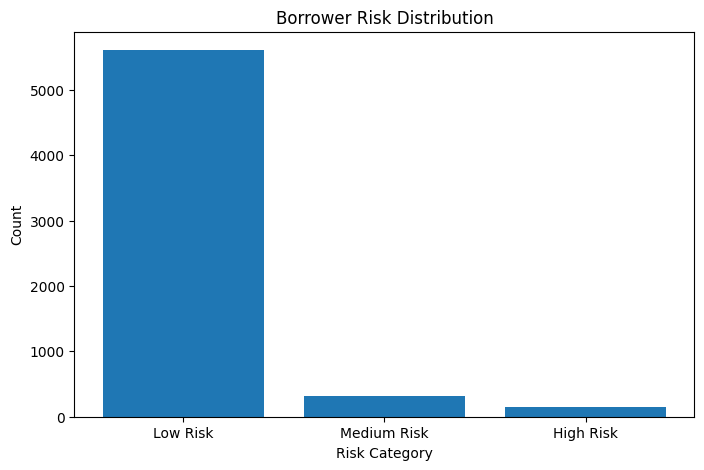

In [46]:
# Risk distribution graph

plt.figure(figsize=(8,5))

risk_counts = df["risk"].value_counts()

plt.bar(risk_counts.index, risk_counts.values)

plt.title("Borrower Risk Distribution")

plt.xlabel("Risk Category")

plt.ylabel("Count")

plt.show()

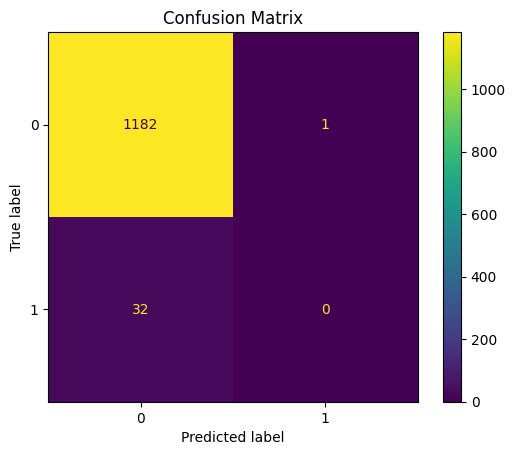

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix")

plt.show()

In [48]:
import joblib

joblib.dump(model, "loan_risk_model.pkl")

['loan_risk_model.pkl']

In [49]:
joblib.dump(X.columns.tolist(), "model_columns.pkl")

['model_columns.pkl']